---
title: Logarithmic Axes
subtitle: DS 2023 | Communicating with Data
---

## Overview

A logarithmic axis is an axis on which **equal distances represent equal ratios**, not equal
differences.

On a **normal (linear) axis**, the gap between $1$ and $2$ is the same size as the gap between
$1{,}001$ and $1{,}002$.

On a **log axis**, the gap between $1$ and $10$ is the same size as the gap between $10$ and $100$,
and the same size again as the gap between $100$ and $1{,}000$.

Each step along the axis is a multiplication, usually by $10$. These steps are called **orders of
magnitude**.

> [!NOTE] By "logarithmic axis" we mean a logarithmically scaled axis. It is an axis onto which a domain has been scaled by a logarithmic function.
>
> We will use the phrases "logarithmic axis" or "logarithmic scale" depending on the context.

## Use cases

Consider using a log axis when one of these is true.

- **The data span several orders of magnitude.** If the largest value is a hundred times the smallest,
a linear axis spends almost all of its length on the few big values and crushes everything else
against the origin.

- **The distribution is strongly right-skewed.** This is the same problem stated in terms of one
variable instead of two. Price, income, population, city size, and file size are all like this.

- **The interesting quantity is a ratio.** On a log axis, equal *percentage* differences look equal,
so two series that stand in a constant proportion to each other appear as parallel lines, however
far apart they are. Applied to a time series, this is how you compare growth rates.


A common example of a logarithmic scale is the **Richter scale** to measure the magnitude of an earthquake. Each increase in the scale is $10$ times the previsous value.


> [!NOTE] Realize that when using a logarithmically scaled axis, your reader must do the mental conversion.
>
> A distance on a log axis no longer means what they expect it to mean, so the axis has to be labeled clearly.

## A simple example

To demonstrate the concept, we will use the `diamonds` data set from Seaborn.

This datawset contains observations of nearly $54{,}000$ round diamonds, with their physical measurements, their grades, and their prices.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

diamonds = sns.load_dataset('diamonds')
diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
diamonds['price'].describe().round(0)

count    53940.0
mean      3933.0
std       3989.0
min        326.0
25%        950.0
50%       2401.0
75%       5324.0
max      18823.0
Name: price, dtype: float64

Note that `price` runs from \$$326$ to \$$18{,}823$ &mdash; a ratio of nearly $58$ to $1$ between the
cheapest stone and the most expensive.

> [!NOTE] Note also that the mean sits well above the median, which is the signature of a right-skewed
variable.

To see the shape of that spread, we can sort the from cheapest to most expensive and plot the values in order.

The x axis is just the rank of the diamond; the y axis is its price.

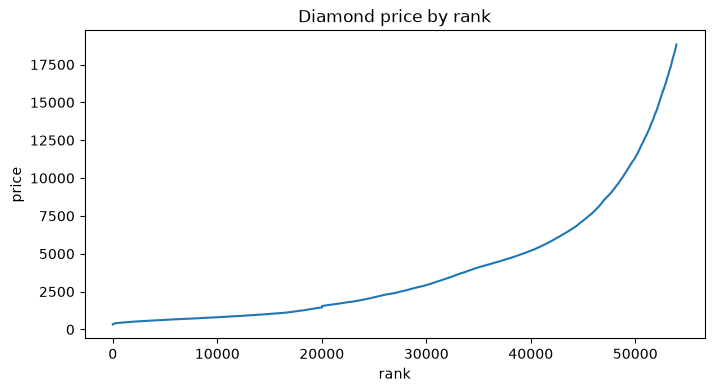

In [4]:
ranked = diamonds['price'].sort_values().reset_index(drop=True)

ranked.plot(figsize=(8,4), title="Diamond price by rank")
plt.xlabel("rank")
plt.ylabel("price")
plt.show()

This is a hockey stick.

The line stays close to the bottom spine for the first thirty thousand diamonds and then climbs steeply at the end.

The y axis is less useful in this plot in that it could be. 

Most of its length separates the few most expensive stones, while the cheap half of the data is squashed into a band so thin you cannot tell a \$$400$ diamond
from a \$$4{,}000$ one &mdash; even though one costs ten times the other.

> [!NOTE] Consider the way we computed rank above.
>
> After applying `.sort_values()`, Pandas returns a series with the index out of its original order.
>
> So, we reset the index to capture the new, ranked order, and drop the old index.

Now let's see the same data with `logy=True`.

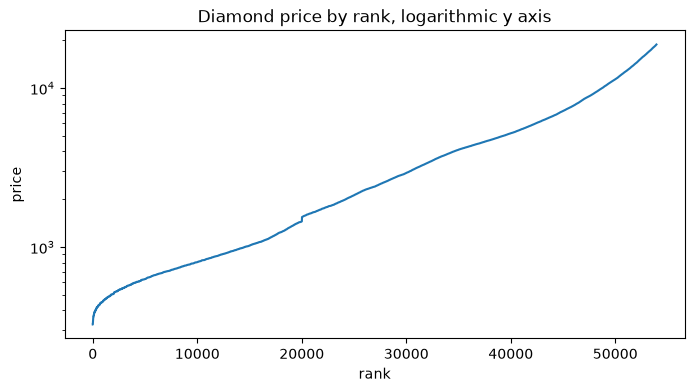

In [5]:
ranked.plot(figsize=(8,4), logy=True, title="Diamond price by rank, logarithmic y axis")
plt.xlabel("rank")
plt.ylabel("price")
plt.show()

The hockey stick straightens out.

The cheap diamonds are now as legible as the expensive ones, and you can read the price at any point
in the ranking instead of only at the top.

> [!TIP] Pandas gives you three parameters for this, available on most of the `.plot` methods:
> | Parameter | Effect |
> |---|---|
> | `logx=True` | Log scale on the x axis |
> | `logy=True` | Log scale on the y axis |
> | `loglog=True` | Log scale on both |

## Why it matters for scatter plots

The same skew distorts a scatter plot, in the same way that occlusion does.

Here we see `price` plotted against `carat` weight, on linear axes.

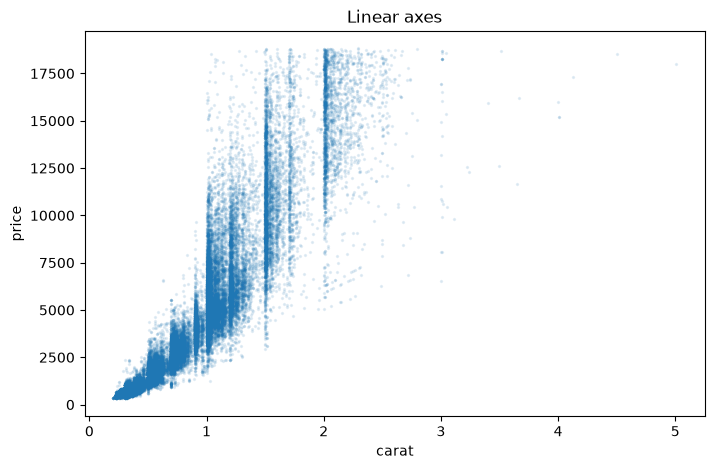

In [6]:
diamonds.plot.scatter(x='carat', y='price', s=2, alpha=.1, figsize=(8,5),
                      title="Linear axes")
plt.show()

The points crowd into the bottom left corner and fan out as they rise.

The relationship is clearly increasing and clearly curved, but most of the data is packed into a
small part of the figure, and the upper right is nearly empty.

You can see this clumping clearly in a hexbin.

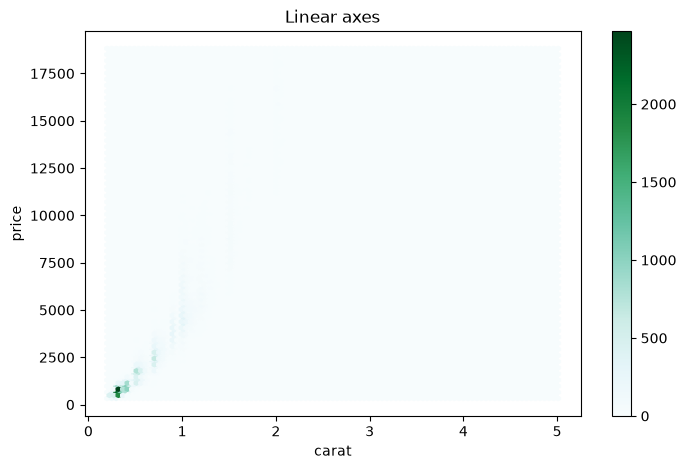

In [7]:
diamonds.plot.hexbin(x='carat', y='price', figsize=(8,5),
                      title="Linear axes")
plt.show()

With `loglog=True` we can scale both axes at once.

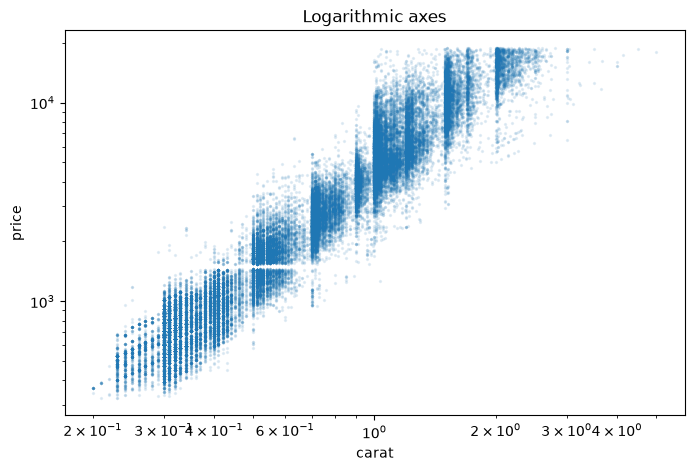

In [8]:
diamonds.plot.scatter(x='carat', y='price', s=2, alpha=.1, figsize=(8,5), loglog=True,
                      title="Logarithmic axes")
plt.show()

Two things happen.

**First**, the curve **straightens into a band**. 

A curve that becomes a straight line under a log-log transformation is a **power law**: price rises roughly as carat raised to a fixed exponent. 

We can recover that exponent with a straight-line fit through the logged values.

In [9]:
slope, intercept = np.polyfit(np.log10(diamonds['carat']), np.log10(diamonds['price']), 1)
print(f"exponent: {slope:.2f}")

exponent: 1.68


An exponent of about $1.68$ means that doubling the weight of a diamond multiplies its price by
roughly $2^{1.68} \approx 3.2$, not by $2$. 

Big stones are disproportionately expensive, and that fact is visible as a *slope* only once both axes are logged.

**Second**, the log axis reveals a structure that was invisible before: the band is **striped**, with
dense vertical lines at round carat weights.

Diamonds cluster at $0.3$, $0.5$, $0.7$, $1.0$, $1.5$ and $2.0$ carats because cutters sacrifice
weight to hit those thresholds. 

The gap just below $1$ carat is the clearest case.

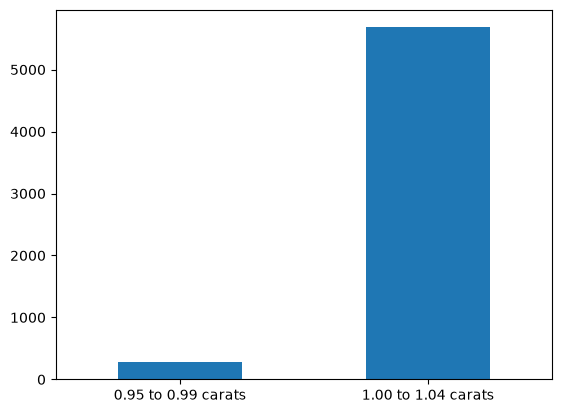

In [10]:
below = diamonds.query("carat >= 0.95 and carat < 1.00").shape[0]
above = diamonds.query("carat >= 1.00 and carat <= 1.04").shape[0]

pd.Series({'0.95 to 0.99 carats': below, '1.00 to 1.04 carats': above}).plot.bar(rot=0)
plt.show()

There are twenty times as many diamonds just above the one-carat line as just below it.

That is not a fact about geology. It is a fact about pricing, and the log axis is what brought it
into view.

## Parallel lines mean equal ratios

The **third use case** is the one people tend to miss.

Below we take the mean price for each combination of carat weight and cut grade, rounding weight to
the nearest tenth of a carat.

In [11]:
diamonds['carat_bin'] = diamonds['carat'].round(1)

by_cut = (
    diamonds
        .groupby(['carat_bin','cut'], observed=True)['price']
        .mean()
        .unstack()
        .loc[0.3:1.5]
)
by_cut.round(0).head()

cut,Ideal,Premium,Very Good,Good,Fair
carat_bin,,,,,
0.3,741.0,717.0,618.0,585.0,799.0
0.4,960.0,935.0,849.0,803.0,928.0
0.5,1693.0,1555.0,1514.0,1409.0,1276.0
0.6,1966.0,1751.0,1792.0,1677.0,1626.0
0.7,2874.0,2501.0,2563.0,2395.0,2071.0


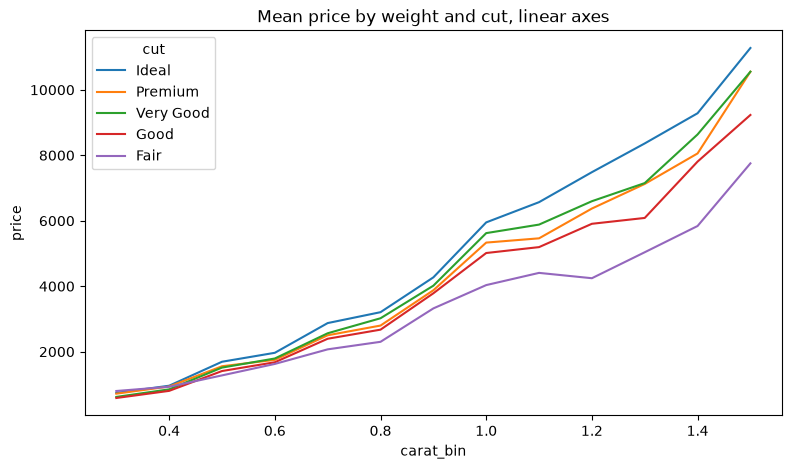

In [12]:
by_cut.plot(figsize=(9,5), title="Mean price by weight and cut, linear axes")
plt.ylabel("price")
plt.show()

On linear axes the five lines fan apart as they rise.

It looks as though the cut grades matter more and more as the stones get bigger.

But that impression is hard to rely on: the lines are separating in dollars, and dollars get larger for everyone.

Here is the same data with `loglog=True`.

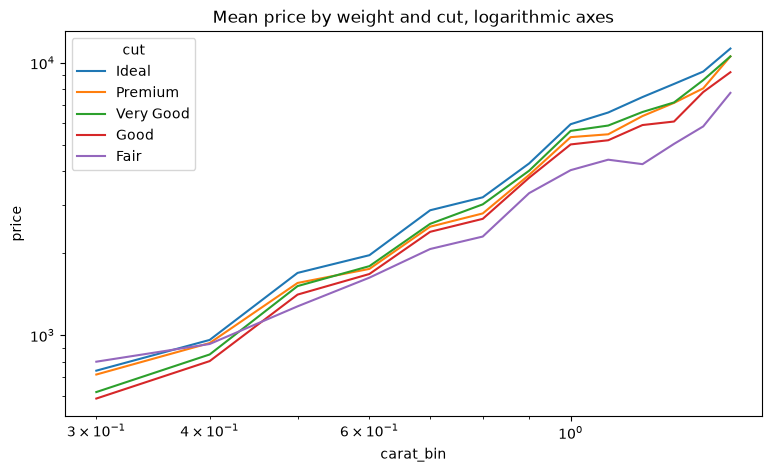

In [13]:
by_cut.plot(figsize=(9,5), loglog=True, title="Mean price by weight and cut, logarithmic axes")
plt.ylabel("price")
plt.show()

The lines are now roughly **parallel**.

Parallel on a log axis means a **constant *ratio***. 

The premium for a better cut is not a growing number of dollars, it is a roughly fixed **percentage**, applied to a price that is itself rising
steeply with weight.

We can read that percentage off the vertical offset between two lines.

In [14]:
# The ratio of Ideal to Good prices at each weight
(by_cut['Ideal'] / by_cut['Good']).describe().round(2)

count    13.00
mean      1.22
std       0.06
min       1.13
25%       1.19
50%       1.20
75%       1.26
max       1.37
dtype: float64

An Ideal-cut diamond costs on the order of $20$ percent more than a Good-cut diamond of the
same weight, at nearly every weight.

That is a single, portable sentence about the data. The linear chart could not have produced it.

## Log axes require ratio data

Everything above assumes something about the **level of measurement** of the variable being logged.

A log axis makes a claim about ratios: it says that the distance from $10$ to $20$ means the same
thing as the distance from $20$ to $40$, because both are a doubling.

That claim is only meaningful on a **ratio scale** &mdash; a scale with a true, non-arbitrary zero,
where saying "twice as much" refers to something real. Price and carat weight both qualify. A
\$$0$ diamond and a $0$-carat diamond are not conventions; they are nothing.

On an **interval scale**, the zero point is a matter of convention. Differences are meaningful but
ratios are not, and a log axis will therefore produce a picture that depends on the unit you
happened to choose.

Temperature is the standard illustration. Take three temperatures and express them three ways.

In [15]:
temps = pd.DataFrame({'celsius': [10, 20, 40]})
temps['fahrenheit'] = temps['celsius'] * 9/5 + 32
temps['kelvin']     = temps['celsius'] + 273.15

# The ratio of each temperature to the first one, in each unit
for unit in ['celsius', 'fahrenheit', 'kelvin']:
    temps[f'{unit}_ratio'] = (temps[unit] / temps[unit].iloc[0]).round(2)

temps

,celsius,fahrenheit,kelvin,celsius_ratio,fahrenheit_ratio,kelvin_ratio
0,10,50.0,283.15,1.0,1.00,1.00
1,20,68.0,293.15,2.0,1.36,1.04
2,40,104.0,313.15,4.0,2.08,1.11


In Celsius the three values are in the ratios $1 : 2 : 4$.

In Fahrenheit the very same three temperatures are in the ratios $1 : 1.36 : 2.08$.

In Kelvin they are $1 : 1.04 : 1.11$.

Since a log axis places points according to those ratios, the three points land at different
spacings in each unit.

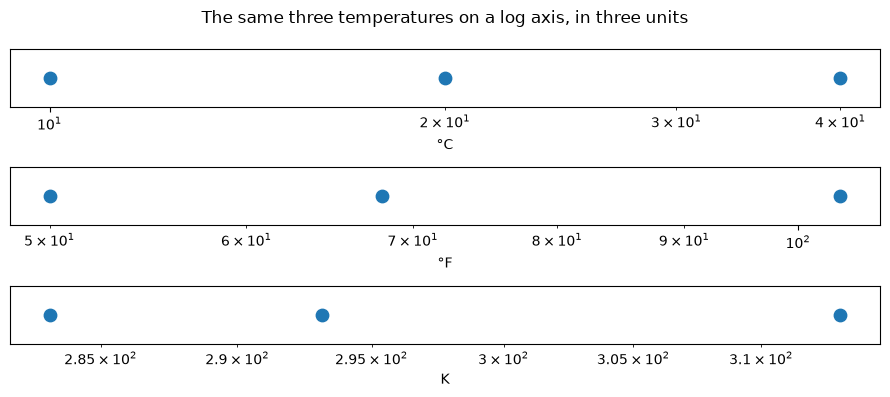

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(9, 4))

for ax, (unit, label) in zip(axes, [('celsius','°C'), ('fahrenheit','°F'), ('kelvin','K')]):
    ax.scatter(temps[unit], [0, 0, 0], s=80)
    ax.set_xscale('log')          # a log axis, set directly on the axes object
    ax.set_yticks([])
    ax.set_xlabel(label)

plt.suptitle("The same three temperatures on a log axis, in three units")
plt.tight_layout()
plt.show()

In Celsius the points are evenly spaced. In Fahrenheit they are not. Nor are they in Kelvin.

Nothing about the world changed between the three panels &mdash; only the arbitrary zero of the
scale. Whatever pattern the reader sees is an artifact of the unit.

Three things follow from this.

**Some interval scales become ratio scales once converted.** Celsius has a conventional zero;
Kelvin has a physical one. $200$ K really is twice $100$ K.

**Calendar years are interval; durations are ratio.** Logging a `year` axis is meaningless, since
year zero is a convention. Logging *age*, *time since purchase*, or *years elapsed* is fine.

**Some variables are already logarithms.** Stellar magnitude, decibels, pH, and the Richter scale
are logs of underlying ratio quantities, which makes them behave like interval scales: differences
are meaningful, ratios are not. Do not log them twice.

> [!note] This is why the y axis of the Hertzsprung–Russell diagram is a plain linear axis even
> though stellar brightness spans an enormous range.
>
> Magnitude *is* the log. A difference of one magnitude is a fixed brightness ratio of about
> $2.512$ anywhere on the axis. Passing `logy=True` there would be logging the data a second time.

Ordinal and nominal variables are out entirely, since their spacings are not quantities at all.

## Cautions

**Zero and negative values cannot be plotted.** The log of zero is undefined and the log of a
negative number is not real, so Matplotlib silently drops those points.

The `diamonds` data has $20$ rows where the depth measurement `z` is recorded as $0$ &mdash; missing
data entered as a zero. They appear on a linear axis and vanish on a log one, with no warning.

In [17]:
int((diamonds['z'] == 0).sum())

20

For a ratio variable that legitimately crosses zero, such as the trade balance data from Week
$4$, the escape hatch is a symmetric log scale &mdash; `ax.set_yscale('symlog')` &mdash; which is
linear through a window around zero and logarithmic outside it. It is an honest tool, but almost no
reader will infer what it is, so it needs a caption.

**A log axis flatters exponential growth.** A curve that doubles every year becomes a straight line,
which reads as steady and unalarming. That is useful for analysis and misleading for persuasion.

**It shrinks outliers.** A value ten times larger than its neighbors moves only one step along the
axis, so extreme points stop looking extreme.

**Label the axis.** A reader who does not notice the scale will misread every distance in the
figure. Tick labels like $10^3$ help, as does saying so in the title or caption.